In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src').exists() and Path('/workspace/src').exists():
    ROOT = Path('/workspace')
sys.path.insert(0, str(ROOT / 'src'))

from kldmPlus.data.csp import CSPTask
from kldmPlus.symmetry.latticeSymmetry import LatticeSymmetry

DATASET_NAME = 'mp20'
SPLIT = 'test'
PER_FAMILY = 20
SEED = 2026
FAMILIES = [
    'triclinic',
    'monoclinic',
    'orthorhombic',
    'tetragonal',
    'trigonal',
    'hexagonal',
    'cubic',
]

torch.set_num_threads(2)
print('root =', ROOT)
print('samples/family =', PER_FAMILY)

MODELS_PROJECT_ROOT: /workspace/.venv/lib/python3.11/site-packages/mattergen
root = /workspace
samples/family = 20


## Step 1: Load the DiffCSP++ \(k\)-space dataset

The dataset already stores the clean primitive lattice in \(k\)-space and a precomputed conventional-chart map `conv_C`. This is exactly the object used later by the conventional projection loss.

In [2]:
task = CSPTask(
    dataset_name=DATASET_NAME,
    lattice_parameterization='x0',
    lattice_representation='diffcsp_k',
)
dataset = task.fit_dataset(split=SPLIT, download=True)
sym = LatticeSymmetry()
print('dataset size =', len(dataset))

dataset_cache action=load dataset=mp_20 split=test reason=fresh path=/workspace/data/mp_20/processed/test
dataset_cache action=from_cache_path:start dataset=mp_20 split=test
dataset_cache action=from_cache_path:done dataset=mp_20 split=test
dataset_cache action=builder_build:start dataset=mp_20 split=test
dataset_cache action=builder_build:done dataset=mp_20 split=test
dataset size = 9046


In [3]:
def family_from_sg(sg: int) -> str:
    sg = int(sg)
    if sg <= 2:
        return 'triclinic'
    if sg <= 15:
        return 'monoclinic'
    if sg <= 74:
        return 'orthorhombic'
    if sg <= 142:
        return 'tetragonal'
    if sg <= 167:
        return 'trigonal'
    if sg <= 194:
        return 'hexagonal'
    return 'cubic'

rng = random.Random(SEED)
valid_by_family = {family: [] for family in FAMILIES}

for idx in range(len(dataset)):
    sample = dataset[idx]
    sg = int(torch.as_tensor(sample.space_group).reshape(-1)[0].item())
    family = family_from_sg(sg)
    if family not in valid_by_family:
        continue
    conv_weight = float(torch.as_tensor(sample.conv_weight).reshape(-1)[0].item())
    conv_fit_error = float(torch.as_tensor(sample.conv_fit_error).reshape(-1)[0].item())
    if conv_weight > 0.5 and np.isfinite(conv_fit_error):
        valid_by_family[family].append(idx)

selection_rows = []
selected_indices = []
for family in FAMILIES:
    pool = list(valid_by_family[family])
    rng.shuffle(pool)
    chosen = pool[:PER_FAMILY]
    if len(chosen) < PER_FAMILY:
        raise RuntimeError(f'Only found {len(chosen)} valid samples for {family}')
    selected_indices.extend(chosen)
    selection_rows.append({'family': family, 'available': len(pool), 'selected': len(chosen)})

selection_df = pd.DataFrame(selection_rows)
display(selection_df)
print('total selected =', len(selected_indices))

/workspace/src/kldmPlus/data/dataset.py:729: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  self._diffcsp_k_out_key: torch.from_numpy(self._diffcsp_k_cache[index]).float().view(1, 6),


,family,available,selected
0,triclinic,376,20
1,monoclinic,1288,20
2,orthorhombic,1725,20
3,tetragonal,1561,20
4,trigonal,964,20
5,hexagonal,975,20
6,cubic,2157,20


total selected = 140


## Step 2: Reconstruct $(P_p)$,$L_c$, and $C_p$

For each selected clean primitive lattice, we decode the model representation into the orientation-free primitive shape


In [4]:
rows = []

for idx in selected_indices:
    sample = dataset[idx]
    sg = int(torch.as_tensor(sample.space_group).reshape(-1)[0].item())
    family = family_from_sg(sg)

    k_p = torch.as_tensor(sample.l, dtype=torch.float64).reshape(1, 6)
    P_p = sym.v2m(k_p).reshape(3, 3).to(dtype=torch.float64)
    C_cached = torch.as_tensor(sample.conv_C, dtype=torch.float64).reshape(3, 3)

    # The conventional lattice used by the auxiliary loss.
    L_c = C_cached @ P_p

    # Thesis equation: C_p = L_c P_p^{-1}.
    C_recomputed = L_c @ torch.linalg.inv(P_p)
    L_reconstructed = C_recomputed @ P_p

    eigvals = torch.linalg.eigvalsh(P_p)
    rows.append({
        'index': int(idx),
        'family': family,
        'space_group': sg,
        'min_eig_Pp': float(eigvals.min().item()),
        'det_Pp': float(torch.linalg.det(P_p).item()),
        'cond_Pp': float(torch.linalg.cond(P_p).item()),
        'max_abs_C_recompute_minus_cached': float((C_recomputed - C_cached).abs().max().item()),
        'max_abs_CpPp_minus_Lc': float((L_reconstructed - L_c).abs().max().item()),
        'fro_abs_CpPp_minus_Lc': float(torch.linalg.matrix_norm(L_reconstructed - L_c).item()),
        'cached_fit_error': float(torch.as_tensor(sample.conv_fit_error).reshape(-1)[0].item()),
    })

map_df = pd.DataFrame(rows)
display(map_df.head())

,index,family,space_group,min_eig_Pp,det_Pp,cond_Pp,max_abs_C_recompute_minus_cached,max_abs_CpPp_minus_Lc,fro_abs_CpPp_minus_Lc,cached_fit_error
0,1901,triclinic,2,5.121751,347.553841,1.685927,2.220446e-16,1.776357e-15,2.788549e-15,2.384186e-06
1,91,triclinic,2,4.926352,271.990377,1.529812,2.220446e-16,8.881784e-16,1.288002e-15,9.607631e-07
2,4920,triclinic,1,3.646400,214.597247,2.575138,1.110223e-16,8.881784e-16,1.120734e-15,9.536743e-07
3,243,triclinic,2,3.257734,100.383337,1.941123,1.110223e-16,8.881784e-16,9.818291e-16,1.750618e-06
4,2875,triclinic,2,3.238065,149.166209,2.370243,1.110223e-16,8.881784e-16,1.135887e-15,1.430511e-06


## Step 3: Check the identity over 20 samples per family
$
The map exists when P_p is invertible. Numerically, this is checked by positive eigenvalues and nonzero determinant. The identity $C_pP_p=L_c$ is checked by the maximum absolute reconstruction error.

In [5]:
summary = map_df.groupby('family').agg(
    n=('index', 'count'),
    min_eig_Pp_min=('min_eig_Pp', 'min'),
    det_Pp_min=('det_Pp', 'min'),
    cond_Pp_median=('cond_Pp', 'median'),
    C_error_max=('max_abs_C_recompute_minus_cached', 'max'),
    reconstruction_error_max=('max_abs_CpPp_minus_Lc', 'max'),
    cached_fit_error_max=('cached_fit_error', 'max'),
).reset_index()

display(summary)

assert (map_df['min_eig_Pp'] > 0).all(), 'Some primitive shapes are not SPD.'
assert (map_df['det_Pp'] > 0).all(), 'Some primitive shapes are singular.'
assert map_df['max_abs_CpPp_minus_Lc'].max() < 1e-8, 'C_p P_p != L_c beyond tolerance.'
assert map_df['max_abs_C_recompute_minus_cached'].max() < 1e-8, 'Recomputed C_p does not match cached conv_C.'

print('PASS: all selected primitive shapes are invertible SPD matrices.')
print('PASS: recomputed C_p = L_c P_p^{-1} matches cached conv_C.')
print('PASS: C_p P_p reconstructs L_c to numerical precision.')

,family,n,min_eig_Pp_min,det_Pp_min,cond_Pp_median,C_error_max,reconstruction_error_max,cached_fit_error_max
0,cubic,20,1.713410,20.120705,2.000000,4.440892e-16,3.552714e-15,0.000004
1,hexagonal,20,2.488890,40.957957,1.752776,1.110223e-16,8.881784e-16,0.000002
2,monoclinic,20,2.737840,101.538739,1.970791,6.661338e-16,1.776357e-15,0.000004
3,orthorhombic,20,2.862746,56.734999,2.155038,4.440892e-16,1.776357e-15,0.000004
4,tetragonal,20,2.961349,43.373986,2.052215,2.220446e-16,3.552714e-15,0.000005
5,triclinic,20,2.862887,94.755987,1.934527,4.440892e-16,2.664535e-15,0.000004
6,trigonal,20,2.130722,45.402143,2.013544,4.440892e-16,7.105427e-15,0.000004


PASS: all selected primitive shapes are invertible SPD matrices.
PASS: recomputed C_p = L_c P_p^{-1} matches cached conv_C.
PASS: C_p P_p reconstructs L_c to numerical precision.


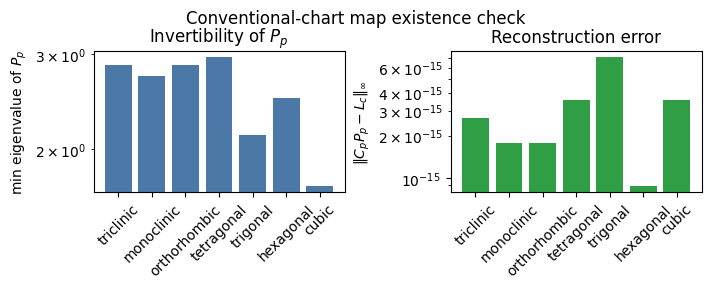

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), constrained_layout=True)

plot_df = map_df.copy()
order = FAMILIES

axes[0].set_title(r'Invertibility of $P_p$')
axes[0].bar(
    order,
    [plot_df.loc[plot_df.family == family, 'min_eig_Pp'].min() for family in order],
    color='#4c78a8',
)
axes[0].set_ylabel(r'min eigenvalue of $P_p$')
axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title(r'Reconstruction error')
axes[1].bar(
    order,
    [plot_df.loc[plot_df.family == family, 'max_abs_CpPp_minus_Lc'].max() for family in order],
    color='#2f9e44',
)
axes[1].set_ylabel(r'$\|C_pP_p-L_c\|_\infty$')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Conventional-chart map existence check', y=1.05)
plt.show()

## Step 4: Why the same map can be reused for predictions

For a fixed crystal, \(C_p\) is computed once from the clean primitive shape and the chosen conventional lattice. A model prediction \(\hat{P}_p\) can then be evaluated in the same conventional chart by

\[
\hat{L}_c = C_p \hat{P}_p.
\]

The next cell applies the same fixed chart map to a small perturbed primitive shape to show that the operation remains well-defined. This is the operation used before applying the space-group projection residual.

In [7]:
noise_scale = 0.03
reuse_rows = []
generator = torch.Generator().manual_seed(SEED)

for idx in selected_indices:
    sample = dataset[idx]
    sg = int(torch.as_tensor(sample.space_group).reshape(-1)[0].item())
    family = family_from_sg(sg)
    k_p = torch.as_tensor(sample.l, dtype=torch.float64).reshape(1, 6)
    P_p = sym.v2m(k_p).reshape(3, 3).to(dtype=torch.float64)
    C_p = torch.as_tensor(sample.conv_C, dtype=torch.float64).reshape(3, 3)

    delta = noise_scale * torch.randn((1, 6), generator=generator, dtype=torch.float64)
    P_hat = sym.v2m(k_p + delta).reshape(3, 3).to(dtype=torch.float64)
    L_hat_c = C_p @ P_hat

    reuse_rows.append({
        'family': family,
        'space_group': sg,
        'det_P_hat': float(torch.linalg.det(P_hat).item()),
        'all_finite_L_hat_c': bool(torch.isfinite(L_hat_c).all().item()),
        'chart_change_fro': float(torch.linalg.matrix_norm(L_hat_c - C_p @ P_p).item()),
    })

reuse_df = pd.DataFrame(reuse_rows)
display(reuse_df.groupby('family').agg(
    n=('space_group', 'count'),
    det_P_hat_min=('det_P_hat', 'min'),
    all_finite=('all_finite_L_hat_c', 'all'),
    chart_change_fro_mean=('chart_change_fro', 'mean'),
).reset_index())

assert reuse_df['all_finite_L_hat_c'].all()
assert (reuse_df['det_P_hat'] > 0).all()
print('PASS: the fixed C_p map can be applied to perturbed/predicted primitive shapes.')

,family,n,det_P_hat_min,all_finite,chart_change_fro_mean
0,cubic,20,17.919239,True,0.555567
1,hexagonal,20,45.855176,True,0.425412
2,monoclinic,20,104.308929,True,0.568925
3,orthorhombic,20,60.508325,True,0.584419
4,tetragonal,20,39.410484,True,0.515410
5,triclinic,20,97.812547,True,0.473827
6,trigonal,20,48.849218,True,0.639133


PASS: the fixed C_p map can be applied to perturbed/predicted primitive shapes.
